# NumPy for Data Science, AI and Generative AI

A practical, code-first guide to NumPy with a focus on how it underpins modern machine learning and large language models.

**What you will learn**

1. The `ndarray`: creation, dtypes, shapes and memory
2. Indexing, slicing, masking and fancy indexing
3. Vectorization and broadcasting
4. Reshaping, stacking and axis-aware operations
5. Math, statistics and aggregation
6. Linear algebra: `matmul`, `einsum`, SVD
7. Random number generation
8. AI and Generative AI patterns written in pure NumPy:
   - Embeddings and cosine similarity search
   - Softmax, temperature, top-k and top-p sampling
   - Scaled dot-product attention, causal masks and multi-head attention
   - Sinusoidal positional encoding
   - Layer normalization
   - Logistic regression trained by gradient descent
   - PCA through SVD
   - int8 quantization
   - Padding and batching variable-length sequences

Every section has a short explanation, runnable code and an example you can modify.

## 0. Setup

NumPy is the foundation of the Python scientific stack. PyTorch, TensorFlow, JAX, scikit-learn, pandas and Hugging Face all either build on NumPy or copy its API. If you understand NumPy well, you understand the core data model behind almost every AI library.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7, 4), "axes.grid": True, "grid.alpha": 0.3})
print("NumPy version:", np.__version__)

NumPy version: 2.4.4


## 1. The ndarray

An `ndarray` is a fixed-type, N-dimensional block of memory. Compared with a Python list it is:

- **Homogeneous**: every element has the same dtype, so operations run in compiled C loops.
- **Compact**: no per-element Python object overhead.
- **Strided**: a view onto memory described by `shape` and `strides`, which makes reshaping and transposing almost free.

### 1.1 Creating arrays

In [2]:
a = np.array([1, 2, 3, 4])
b = np.array([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])

print("a:", a, "| dtype:", a.dtype, "| shape:", a.shape)
print("b:\n", b)
print("b dtype:", b.dtype, "| shape:", b.shape, "| ndim:", b.ndim, "| size:", b.size)

a: [1 2 3 4] | dtype: int64 | shape: (4,)
b:
 [[1. 2. 3.]
 [4. 5. 6.]]
b dtype: float64 | shape: (2, 3) | ndim: 2 | size: 6


In [3]:
print("zeros     :", np.zeros((2, 3)).tolist())
print("ones      :", np.ones((2, 2)).tolist())
print("full      :", np.full((2, 2), 7).tolist())
print("eye       :\n", np.eye(3))
print("arange    :", np.arange(0, 10, 2))
print("linspace  :", np.linspace(0, 1, 5))
print("logspace  :", np.logspace(0, 3, 4))
print("empty_like:", np.empty_like(b).shape)

zeros     : [[0.0, 0.0, 0.0], [0.0, 0.0, 0.0]]
ones      : [[1.0, 1.0], [1.0, 1.0]]
full      : [[7, 7], [7, 7]]
eye       :
 [[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
arange    : [0 2 4 6 8]
linspace  : [0.   0.25 0.5  0.75 1.  ]
logspace  : [   1.   10.  100. 1000.]
empty_like: (2, 3)


### 1.2 Data types and memory

Dtype choice matters a great deal in AI work. Model weights are commonly stored in `float32`, `float16`, `bfloat16` (not native in NumPy) or `int8` after quantization. A 7 billion parameter model needs roughly 28 GB in float32, 14 GB in float16 and 7 GB in int8.

In [4]:
x32 = np.ones(1_000_000, dtype=np.float32)
x64 = np.ones(1_000_000, dtype=np.float64)
x16 = np.ones(1_000_000, dtype=np.float16)
x8 = np.ones(1_000_000, dtype=np.int8)

for name, arr in [("float64", x64), ("float32", x32), ("float16", x16), ("int8", x8)]:
    print(f"{name:8s} -> {arr.nbytes / 1e6:6.2f} MB for 1M elements")

params = 7e9
for name, bytes_per in [("float32", 4), ("float16", 2), ("int8", 1)]:
    print(f"7B parameters in {name}: {params * bytes_per / 1e9:.0f} GB")

float64  ->   8.00 MB for 1M elements
float32  ->   4.00 MB for 1M elements
float16  ->   2.00 MB for 1M elements
int8     ->   1.00 MB for 1M elements
7B parameters in float32: 28 GB
7B parameters in float16: 14 GB
7B parameters in int8: 7 GB


In [5]:
# Casting and precision
v = np.array([0.1, 0.2, 0.3], dtype=np.float64)
print(v.astype(np.float32))
print(v.astype(np.float16))

# Overflow behaviour is silent for integers
print(np.array([250], dtype=np.uint8) + np.array([10], dtype=np.uint8))

[0.1 0.2 0.3]
[0.1 0.2 0.3]
[4]


### 1.3 Views versus copies

Slicing returns a **view** (shares memory). Fancy indexing and boolean masking return **copies**. Forgetting this is a common source of bugs when preparing training data.

In [6]:
base = np.arange(10)
view = base[2:6]
view[0] = 99
print("base after editing the view:", base)
print("shares memory:", np.shares_memory(base, view))

copy = base[[2, 3, 4]]
copy[0] = -1
print("base after editing the copy:", base)
print("shares memory:", np.shares_memory(base, copy))

base after editing the view: [ 0  1 99  3  4  5  6  7  8  9]
shares memory: True
base after editing the copy: [ 0  1 99  3  4  5  6  7  8  9]
shares memory: False


## 2. Indexing, slicing and masking

### 2.1 Basic slicing

In [7]:
m = np.arange(24).reshape(4, 6)
print(m)
print("\nrow 1        :", m[1])
print("column 2     :", m[:, 2])
print("sub-block    :\n", m[1:3, 2:5])
print("every 2nd col:", m[0, ::2])
print("reversed row :", m[0, ::-1])

[[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]
 [12 13 14 15 16 17]
 [18 19 20 21 22 23]]

row 1        : [ 6  7  8  9 10 11]
column 2     : [ 2  8 14 20]
sub-block    :
 [[ 8  9 10]
 [14 15 16]]
every 2nd col: [0 2 4]
reversed row : [5 4 3 2 1 0]


### 2.2 Boolean masks

Masks are everywhere in AI: attention masks, padding masks, filtering low-confidence predictions, and selecting samples by label.

In [8]:
scores = np.array([0.91, 0.12, 0.55, 0.78, 0.33, 0.97])
labels = np.array(["cat", "dog", "cat", "bird", "dog", "cat"])

confident = scores > 0.5
print("mask          :", confident)
print("confident     :", scores[confident])
print("cat scores    :", scores[labels == "cat"])
print("cat and > 0.9 :", scores[(labels == "cat") & (scores > 0.9)])

# np.where for conditional replacement
print("clipped to 0.5:", np.where(scores > 0.5, scores, 0.5))

mask          : [ True False  True  True False  True]
confident     : [0.91 0.55 0.78 0.97]
cat scores    : [0.91 0.55 0.97]
cat and > 0.9 : [0.91 0.97]
clipped to 0.5: [0.91 0.5  0.55 0.78 0.5  0.97]


### 2.3 Fancy indexing

Passing integer arrays selects arbitrary elements. In language models this is how an **embedding lookup** works: token IDs index rows of an embedding matrix.

In [9]:
vocab_size, d_model = 10, 4
rng = np.random.default_rng(0)
embedding_matrix = rng.normal(size=(vocab_size, d_model)).round(2)

token_ids = np.array([3, 1, 4, 1, 5])
token_vectors = embedding_matrix[token_ids]

print("token ids:", token_ids)
print("looked-up embeddings shape:", token_vectors.shape)
print(token_vectors)

token ids: [3 1 4 1 5]
looked-up embeddings shape: (5, 4)
[[-2.33 -0.22 -1.25 -0.73]
 [-0.54  0.36  1.3   0.95]
 [-0.54 -0.32  0.41  1.04]
 [-0.54  0.36  1.3   0.95]
 [-0.13  1.37 -0.67  0.35]]


## 3. Vectorization and broadcasting

### 3.1 Why vectorize

Python loops execute one interpreted step at a time. NumPy pushes the loop into optimized C and often SIMD instructions. The difference is commonly 10x to 100x or more.

python loop :   167.69 ms
numpy dot   :     1.12 ms
speedup     :    150.3x
results match: True


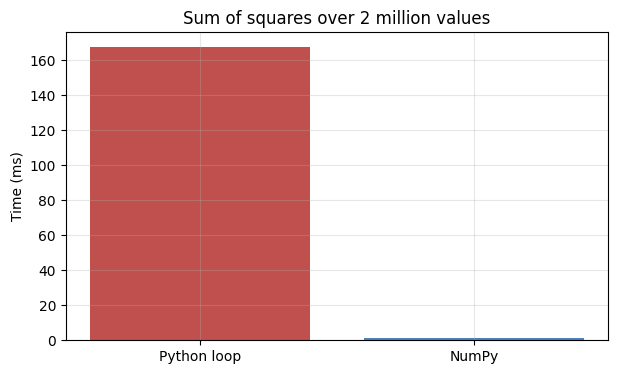

In [10]:
n = 2_000_000
x = np.random.default_rng(1).random(n)

t0 = time.perf_counter()
total_loop = 0.0
for v in x.tolist():
    total_loop += v * v
t_loop = time.perf_counter() - t0

t0 = time.perf_counter()
total_vec = np.dot(x, x)
t_vec = time.perf_counter() - t0

print(f"python loop : {t_loop * 1000:8.2f} ms")
print(f"numpy dot   : {t_vec * 1000:8.2f} ms")
print(f"speedup     : {t_loop / t_vec:8.1f}x")
print("results match:", np.isclose(total_loop, total_vec))

fig, ax = plt.subplots()
ax.bar(["Python loop", "NumPy"], [t_loop * 1000, t_vec * 1000], color=["#c0504d", "#4f81bd"])
ax.set_ylabel("Time (ms)")
ax.set_title("Sum of squares over 2 million values")
plt.show()

### 3.2 Broadcasting rules

When two arrays have different shapes, NumPy aligns them from the **trailing** dimension. Two dimensions are compatible if they are equal or one of them is 1. A dimension of size 1 is virtually stretched to match, without copying data.

Typical AI uses: adding a bias vector to every row in a batch, subtracting a mean per feature, and applying per-channel scales.

In [11]:
batch = np.arange(12, dtype=float).reshape(4, 3)      # (batch=4, features=3)
bias = np.array([10.0, 20.0, 30.0])                   # (features=3,)

print("batch + bias:\n", batch + bias)

col_means = batch.mean(axis=0)                        # (3,)
centered = batch - col_means                          # broadcast over rows
print("\ncentered column means:", centered.mean(axis=0))

# Outer-style combination using a new axis
rows = np.arange(4)[:, None]    # (4, 1)
cols = np.arange(3)[None, :]    # (1, 3)
print("\nrows + cols:\n", rows + cols)

batch + bias:
 [[10. 21. 32.]
 [13. 24. 35.]
 [16. 27. 38.]
 [19. 30. 41.]]

centered column means: [0. 0. 0.]

rows + cols:
 [[0 1 2]
 [1 2 3]
 [2 3 4]
 [3 4 5]]


In [12]:
# Pairwise distances between two sets of points without any Python loop
A = np.random.default_rng(2).normal(size=(5, 2))
B = np.random.default_rng(3).normal(size=(4, 2))

diff = A[:, None, :] - B[None, :, :]        # (5, 1, 2) - (1, 4, 2) -> (5, 4, 2)
dist = np.sqrt((diff ** 2).sum(axis=-1))    # (5, 4)
print("distance matrix shape:", dist.shape)
print(dist.round(2))

distance matrix shape: (5, 4)
[[2.75 0.23 0.71 2.23]
 [2.46 2.05 2.23 2.73]
 [3.71 2.2  2.63 4.06]
 [4.08 1.53 1.   1.97]
 [2.67 0.14 0.81 2.32]]


## 4. Reshaping, stacking and axes

### 4.1 reshape, transpose, flatten

In [13]:
t = np.arange(24)
print("reshape (2,3,4):", t.reshape(2, 3, 4).shape)
print("reshape (4,-1)  :", t.reshape(4, -1).shape)

img = np.arange(2 * 3 * 4).reshape(2, 3, 4)   # (batch, height, width)
print("transpose axes  :", img.transpose(0, 2, 1).shape)
print("swapaxes        :", np.swapaxes(img, 1, 2).shape)
print("add axis        :", img[:, None, :, :].shape)
print("squeeze         :", img[:, None, :, :].squeeze().shape)
print("ravel           :", img.ravel().shape)

reshape (2,3,4): (2, 3, 4)
reshape (4,-1)  : (4, 6)
transpose axes  : (2, 4, 3)
swapaxes        : (2, 4, 3)
add axis        : (2, 1, 3, 4)
squeeze         : (2, 3, 4)
ravel           : (24,)


### 4.2 Stacking and splitting

In [14]:
a = np.array([[1, 2], [3, 4]])
b = np.array([[5, 6], [7, 8]])

print("vstack:\n", np.vstack([a, b]))
print("hstack:\n", np.hstack([a, b]))
print("stack axis=0 shape:", np.stack([a, b], axis=0).shape)
print("concatenate axis=1:\n", np.concatenate([a, b], axis=1))

big = np.arange(12).reshape(6, 2)
print("split into 3 mini-batches:", [p.shape for p in np.split(big, 3)])

vstack:
 [[1 2]
 [3 4]
 [5 6]
 [7 8]]
hstack:
 [[1 2 5 6]
 [3 4 7 8]]
stack axis=0 shape: (2, 2, 2)
concatenate axis=1:
 [[1 2 5 6]
 [3 4 7 8]]
split into 3 mini-batches: [(2, 2), (2, 2), (2, 2)]


### 4.3 Aggregations along axes

The `axis` argument names the dimension that gets **collapsed**. For a `(batch, seq, features)` tensor, `axis=-1` reduces over features, which is what layer normalization and softmax do.

In [15]:
x = np.random.default_rng(4).normal(size=(2, 3, 4))   # (batch, seq, features)

print("sum all           :", x.sum().round(3))
print("mean over batch   :", x.mean(axis=0).shape)
print("mean over features:", x.mean(axis=-1).shape)
print("keepdims          :", x.mean(axis=-1, keepdims=True).shape)
print("argmax last axis  :\n", x.argmax(axis=-1))

sum all           : -1.676
mean over batch   : (3, 4)
mean over features: (2, 3)
keepdims          : (2, 3, 1)
argmax last axis  :
 [[2 3 3]
 [3 1 2]]


## 5. Math, statistics and sorting

NumPy provides universal functions (ufuncs) that operate element-wise: `exp`, `log`, `sqrt`, `tanh`, `maximum`, `clip` and many more. Activation functions in neural networks are just ufuncs.

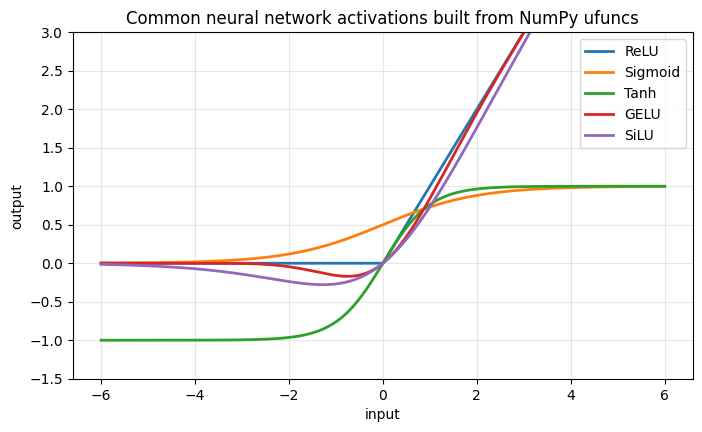

In [16]:
z = np.linspace(-6, 6, 400)

relu = np.maximum(0, z)
sigmoid = 1 / (1 + np.exp(-z))
tanh = np.tanh(z)
gelu = 0.5 * z * (1 + np.tanh(np.sqrt(2 / np.pi) * (z + 0.044715 * z ** 3)))
silu = z * sigmoid

fig, ax = plt.subplots(figsize=(8, 4.5))
for name, y in [("ReLU", relu), ("Sigmoid", sigmoid), ("Tanh", tanh), ("GELU", gelu), ("SiLU", silu)]:
    ax.plot(z, y, label=name, linewidth=2)
ax.set_ylim(-1.5, 3)
ax.set_title("Common neural network activations built from NumPy ufuncs")
ax.set_xlabel("input")
ax.set_ylabel("output")
ax.legend()
plt.show()

In [17]:
data = np.random.default_rng(5).normal(loc=50, scale=10, size=1000)

print("mean   :", data.mean().round(2))
print("std    :", data.std().round(2))
print("median :", np.median(data).round(2))
print("p5/p95 :", np.percentile(data, [5, 95]).round(2))
print("min/max:", data.min().round(2), data.max().round(2))

# Standardization, a standard preprocessing step
standardized = (data - data.mean()) / data.std()
print("after standardization -> mean %.3f, std %.3f" % (standardized.mean(), standardized.std()))

# Sorting utilities
vals = np.array([0.2, 0.9, 0.4, 0.7])
print("argsort           :", np.argsort(vals))
print("top-2 indices     :", np.argsort(vals)[-2:][::-1])
print("argpartition top-2:", np.sort(np.argpartition(vals, -2)[-2:]))

mean   : 50.02
std    : 9.94
median : 50.2
p5/p95 : [33.94 66.67]
min/max: 17.16 81.12
after standardization -> mean -0.000, std 1.000
argsort           : [0 2 3 1]
top-2 indices     : [1 3]
argpartition top-2: [1 3]


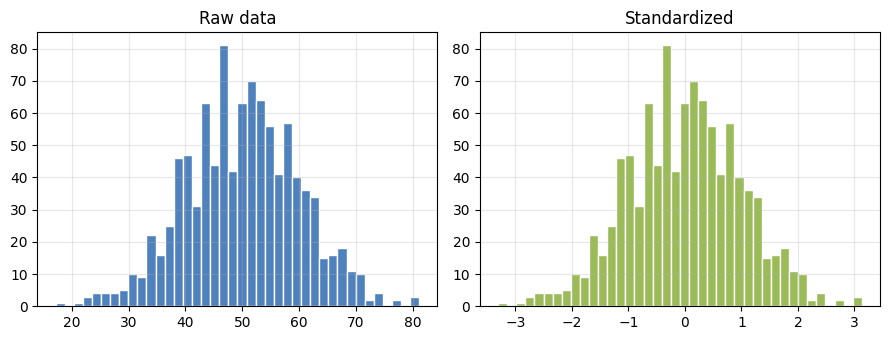

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].hist(data, bins=40, color="#4f81bd", edgecolor="white")
axes[0].set_title("Raw data")
axes[1].hist(standardized, bins=40, color="#9bbb59", edgecolor="white")
axes[1].set_title("Standardized")
plt.tight_layout()
plt.show()

## 6. Linear algebra

Almost everything in deep learning is matrix multiplication. A Transformer layer is dominated by `matmul` operations, and GPUs are built to run them fast. NumPy's `np.linalg` module gives you the same operations on the CPU, backed by BLAS and LAPACK.

### 6.1 Dot products, matmul and the `@` operator

In [19]:
u = np.array([1.0, 2.0, 3.0])
v = np.array([4.0, 5.0, 6.0])

print("dot      :", np.dot(u, v))
print("norm     :", np.linalg.norm(u).round(4))
print("cosine   :", (u @ v / (np.linalg.norm(u) * np.linalg.norm(v))).round(4))

W = np.random.default_rng(6).normal(size=(3, 2))
X = np.random.default_rng(7).normal(size=(5, 3))
print("\n(5x3) @ (3x2) ->", (X @ W).shape)

# Batched matmul: leading dimensions are broadcast
Q = np.random.default_rng(8).normal(size=(2, 4, 8, 16))   # (batch, heads, seq, d_head)
K = np.random.default_rng(9).normal(size=(2, 4, 8, 16))
scores = Q @ K.swapaxes(-1, -2)
print("batched attention scores shape:", scores.shape)

dot      : 32.0
norm     : 3.7417
cosine   : 0.9746

(5x3) @ (3x2) -> (5, 2)
batched attention scores shape: (2, 4, 8, 8)


### 6.2 einsum

`np.einsum` expresses tensor contractions with index notation. It is compact, explicit about shapes, and widely used in research code.

In [20]:
A = np.random.default_rng(10).normal(size=(3, 4))
B = np.random.default_rng(11).normal(size=(4, 5))

print("matmul via einsum ok :", np.allclose(np.einsum("ij,jk->ik", A, B), A @ B))
print("trace via einsum     :", np.isclose(np.einsum("ii->", np.eye(4) * 2), 8.0))

# Batched attention scores: (b,h,q,d) x (b,h,k,d) -> (b,h,q,k)
scores_einsum = np.einsum("bhqd,bhkd->bhqk", Q, K)
print("attention einsum ok  :", np.allclose(scores_einsum, scores))

matmul via einsum ok : True
trace via einsum     : True
attention einsum ok  : True


### 6.3 Solving systems, inverses and decompositions

In [21]:
A = np.array([[3.0, 1.0], [1.0, 2.0]])
b = np.array([9.0, 8.0])

x = np.linalg.solve(A, b)
print("solve(A, b)        :", x)
print("check A @ x == b   :", np.allclose(A @ x, b))
print("determinant        :", np.linalg.det(A).round(3))
print("inverse            :\n", np.linalg.inv(A).round(3))

eigvals, eigvecs = np.linalg.eigh(A)
print("eigenvalues        :", eigvals.round(3))

U, S, Vt = np.linalg.svd(np.random.default_rng(12).normal(size=(6, 4)), full_matrices=False)
print("SVD shapes         :", U.shape, S.shape, Vt.shape)

solve(A, b)        : [2. 3.]
check A @ x == b   : True
determinant        : 5.0
inverse            :
 [[ 0.4 -0.2]
 [-0.2  0.6]]
eigenvalues        : [1.382 3.618]
SVD shapes         : (6, 4) (4,) (4, 4)


### 6.4 Low-rank approximation, the idea behind LoRA

Fine-tuning large language models with LoRA (Low-Rank Adaptation) represents a weight update as the product of two thin matrices. The SVD shows why this works: many weight matrices are well approximated by a few singular values.

Below we build a matrix that is approximately rank 5 plus noise, then reconstruct it with increasing rank.

full matrix parameters      : 12000
rank-5 factors parameters   : 1100 (9.2% of full)


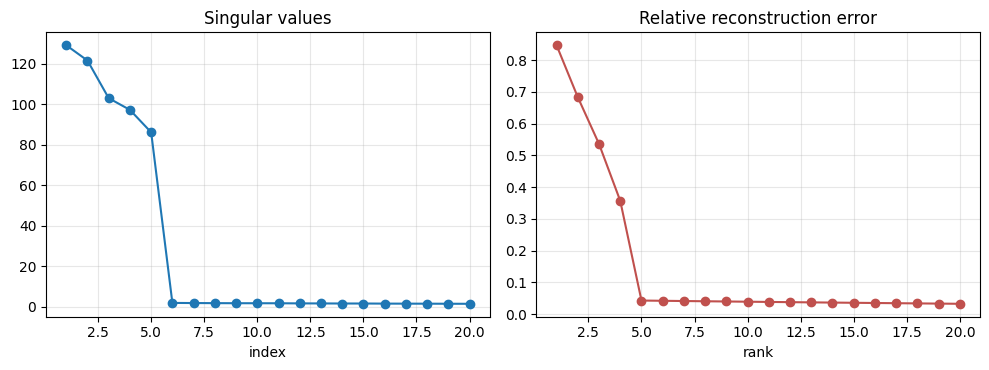

In [22]:
rng = np.random.default_rng(13)
n, m, true_rank = 120, 100, 5
W = rng.normal(size=(n, true_rank)) @ rng.normal(size=(true_rank, m)) + 0.1 * rng.normal(size=(n, m))

U, S, Vt = np.linalg.svd(W, full_matrices=False)

ranks = np.arange(1, 21)
errors = []
for r in ranks:
    W_r = (U[:, :r] * S[:r]) @ Vt[:r]
    errors.append(np.linalg.norm(W - W_r) / np.linalg.norm(W))

full_params = n * m
r = 5
lowrank_params = r * (n + m)
print(f"full matrix parameters      : {full_params}")
print(f"rank-{r} factors parameters   : {lowrank_params} ({lowrank_params / full_params:.1%} of full)")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(np.arange(1, 21), S[:20], marker="o")
axes[0].set_title("Singular values")
axes[0].set_xlabel("index")
axes[1].plot(ranks, errors, marker="o", color="#c0504d")
axes[1].set_title("Relative reconstruction error")
axes[1].set_xlabel("rank")
plt.tight_layout()
plt.show()

## 7. Random numbers

Use the modern `np.random.default_rng(seed)` generator. It is statistically better than the legacy `np.random.seed` API and lets you pass independent generators to different parts of a program, which makes experiments reproducible.

In AI, randomness appears in weight initialization, dropout, data shuffling, train/test splits, data augmentation and token sampling.

In [23]:
rng = np.random.default_rng(42)

print("uniform  :", rng.random(3).round(3))
print("normal   :", rng.normal(0, 1, 3).round(3))
print("integers :", rng.integers(0, 10, size=5))
print("choice   :", rng.choice(["a", "b", "c"], size=5, p=[0.7, 0.2, 0.1]))
print("permute  :", rng.permutation(8))

# Reproducibility
print(np.array_equal(np.random.default_rng(7).random(4), np.random.default_rng(7).random(4)))

uniform  : [0.774 0.439 0.859]
normal   : [ 0.941 -1.951 -1.302]
integers : [7 7 7 7 5]
choice   : ['a' 'a' 'c' 'a' 'b']
permute  : [0 1 7 4 5 2 3 6]
True


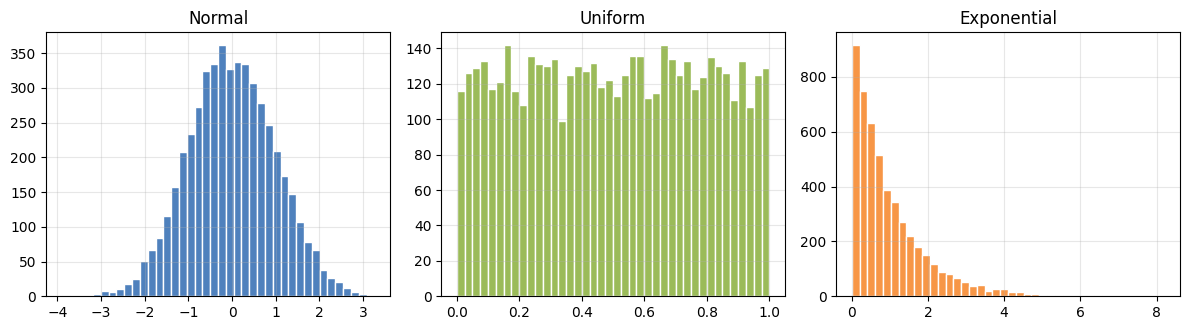

In [24]:
rng = np.random.default_rng(0)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
axes[0].hist(rng.normal(size=5000), bins=40, color="#4f81bd", edgecolor="white")
axes[0].set_title("Normal")
axes[1].hist(rng.uniform(size=5000), bins=40, color="#9bbb59", edgecolor="white")
axes[1].set_title("Uniform")
axes[2].hist(rng.exponential(size=5000), bins=40, color="#f79646", edgecolor="white")
axes[2].set_title("Exponential")
plt.tight_layout()
plt.show()

### 7.1 Weight initialization

Training stability depends on the scale of initial weights. Two classic schemes:

- **Xavier / Glorot**: variance `2 / (fan_in + fan_out)`, suited to tanh and sigmoid.
- **He / Kaiming**: variance `2 / fan_in`, suited to ReLU.

The experiment below passes data through 10 ReLU layers with different initialization scales and plots the standard deviation of activations at every layer.

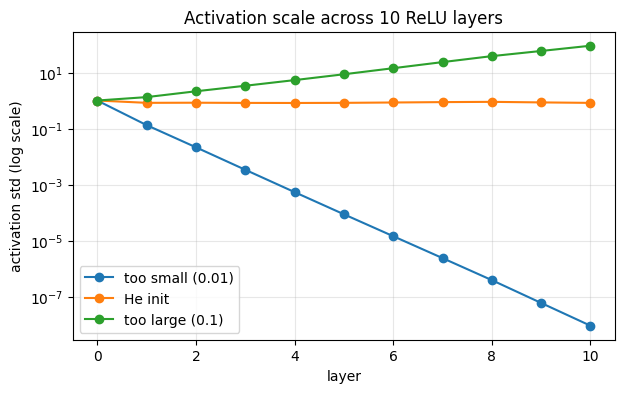

In [25]:
def forward_stds(scale_fn, depth=10, width=512, seed=0):
    rng = np.random.default_rng(seed)
    x = rng.normal(size=(256, width))
    stds = [x.std()]
    for _ in range(depth):
        W = rng.normal(size=(width, width)) * scale_fn(width)
        x = np.maximum(0, x @ W)
        stds.append(x.std())
    return stds

schemes = {
    "too small (0.01)": lambda fan_in: 0.01,
    "He init": lambda fan_in: np.sqrt(2.0 / fan_in),
    "too large (0.1)": lambda fan_in: 0.1,
}

fig, ax = plt.subplots()
for name, fn in schemes.items():
    ax.plot(forward_stds(fn), marker="o", label=name)
ax.set_yscale("log")
ax.set_xlabel("layer")
ax.set_ylabel("activation std (log scale)")
ax.set_title("Activation scale across 10 ReLU layers")
ax.legend()
plt.show()

## 8. NumPy in AI and Generative AI

The remaining sections implement the building blocks of modern AI systems using only NumPy. They are small enough to read in one sitting and accurate enough to match what frameworks do internally.

### 8.1 Embeddings and cosine similarity search

Text, images and audio are converted to vectors called **embeddings**. Semantic search and Retrieval-Augmented Generation (RAG) work by finding the stored vectors closest to a query vector. The standard similarity measure is cosine similarity.

Here we build a toy embedding space with three topic clusters and run a nearest-neighbour query entirely with matrix operations.

In [26]:
rng = np.random.default_rng(21)
dim = 32

topics = {"cooking": 0, "space": 1, "finance": 2}
centers = rng.normal(size=(3, dim)) * 3

docs = []
doc_topic = []
for t, c in enumerate(centers):
    docs.append(c + rng.normal(size=(40, dim)))
    doc_topic += [t] * 40
docs = np.vstack(docs)                    # (120, 32) corpus matrix
doc_topic = np.array(doc_topic)

def normalize(M, eps=1e-12):
    return M / (np.linalg.norm(M, axis=-1, keepdims=True) + eps)

def top_k_similar(query, corpus, k=5):
    sims = normalize(corpus) @ normalize(query)    # cosine similarities for the whole corpus at once
    idx = np.argsort(-sims)[:k]
    return idx, sims[idx]

query = centers[1] + rng.normal(size=dim)          # a "space" style query
idx, sims = top_k_similar(query, docs, k=5)

inv_topics = {v: k for k, v in topics.items()}
for i, s in zip(idx, sims):
    print(f"doc {i:3d}  topic={inv_topics[doc_topic[i]]:8s} cosine={s:.3f}")

doc  44  topic=space    cosine=0.948
doc  61  topic=space    cosine=0.928
doc  75  topic=space    cosine=0.925
doc  45  topic=space    cosine=0.922
doc  51  topic=space    cosine=0.917


**Scaling note.** The same code works for millions of vectors if you keep the corpus matrix pre-normalized and use `float32`. Vector databases such as FAISS use the same math with approximate indexes to avoid scanning every row.

### 8.2 Visualizing embeddings with PCA via SVD

High-dimensional embeddings cannot be plotted directly. Principal Component Analysis projects them onto the directions of greatest variance. It is a few lines of NumPy: center the data, run SVD, and multiply by the top components.

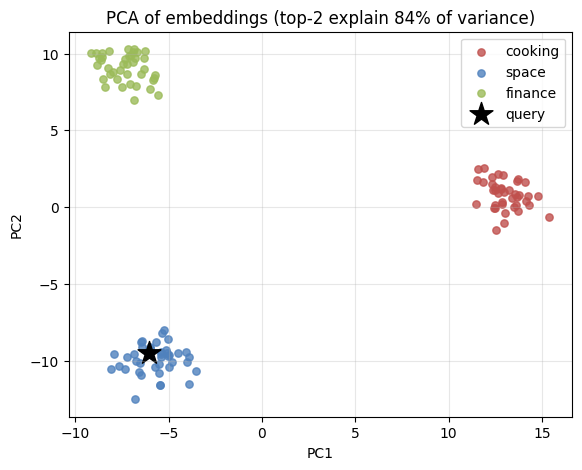

In [27]:
def pca(X, n_components=2):
    Xc = X - X.mean(axis=0, keepdims=True)
    U, S, Vt = np.linalg.svd(Xc, full_matrices=False)
    explained = (S ** 2) / (S ** 2).sum()
    return Xc @ Vt[:n_components].T, explained

proj, explained = pca(docs, 2)
q_proj = (query - docs.mean(axis=0)) @ np.linalg.svd(docs - docs.mean(axis=0), full_matrices=False)[2][:2].T

colors = ["#c0504d", "#4f81bd", "#9bbb59"]
fig, ax = plt.subplots(figsize=(6.5, 5))
for t, name in inv_topics.items():
    pts = proj[doc_topic == t]
    ax.scatter(pts[:, 0], pts[:, 1], s=28, color=colors[t], label=name, alpha=0.8)
ax.scatter(*q_proj, marker="*", s=300, color="black", label="query")
ax.set_title(f"PCA of embeddings (top-2 explain {explained[:2].sum():.0%} of variance)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
plt.show()

### 8.3 Softmax and numerical stability

A language model ends with a vector of **logits**, one per vocabulary token. Softmax converts logits into probabilities. A naive implementation overflows for large values, so production code subtracts the maximum first. This does not change the result because softmax is invariant to constant shifts.

In [28]:
def softmax_naive(x):
    e = np.exp(x)
    return e / e.sum()

def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)   # stability trick
    e = np.exp(x)
    return e / e.sum(axis=axis, keepdims=True)

logits = np.array([1000.0, 1001.0, 1002.0])

with np.errstate(all="ignore"):
    print("naive :", softmax_naive(logits))
print("stable:", softmax(logits).round(4))

naive : [nan nan nan]
stable: [0.09   0.2447 0.6652]


### 8.4 Temperature, top-k and top-p sampling

When a Generative AI model produces text, it samples the next token from a probability distribution. Three controls shape that distribution:

- **Temperature** divides the logits. Values below 1 sharpen the distribution (more deterministic); values above 1 flatten it (more random).
- **Top-k** keeps only the `k` most likely tokens.
- **Top-p (nucleus)** keeps the smallest set of tokens whose cumulative probability reaches `p`.

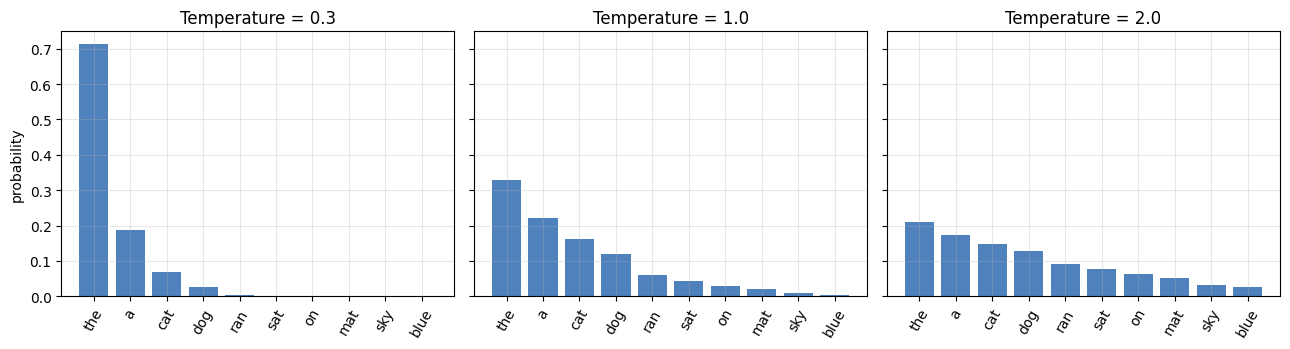

In [29]:
vocab = np.array(["the", "a", "cat", "dog", "ran", "sat", "on", "mat", "sky", "blue"])
logits = np.array([3.2, 2.8, 2.5, 2.2, 1.5, 1.2, 0.8, 0.4, -0.5, -1.0])

def apply_temperature(logits, T):
    return logits / max(T, 1e-8)

def top_k_filter(probs, k):
    out = np.zeros_like(probs)
    idx = np.argpartition(probs, -k)[-k:]
    out[idx] = probs[idx]
    return out / out.sum()

def top_p_filter(probs, p):
    order = np.argsort(-probs)
    cum = np.cumsum(probs[order])
    cutoff = np.searchsorted(cum, p) + 1          # include the token that crosses p
    keep = order[:cutoff]
    out = np.zeros_like(probs)
    out[keep] = probs[keep]
    return out / out.sum()

def sample(probs, rng):
    return rng.choice(len(probs), p=probs)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), sharey=True)
for ax, T in zip(axes, [0.3, 1.0, 2.0]):
    ax.bar(vocab, softmax(apply_temperature(logits, T)), color="#4f81bd")
    ax.set_title(f"Temperature = {T}")
    ax.tick_params(axis="x", rotation=60)
axes[0].set_ylabel("probability")
plt.tight_layout()
plt.show()

In [30]:
probs = softmax(logits)

def show(name, p):
    kept = {str(t): round(float(v), 3) for t, v in zip(vocab, p) if v > 0}
    print(f"{name:14s}", kept)

show("base probs", probs)
show("top-k (k=3)", top_k_filter(probs, 3))
show("top-p (p=0.8)", top_p_filter(probs, 0.8))

rng = np.random.default_rng(5)
draws = [str(vocab[sample(top_p_filter(softmax(apply_temperature(logits, 0.8)), 0.9), rng)]) for _ in range(12)]
print("\n12 sampled tokens (T=0.8, top-p=0.9):", draws)

base probs    

 {'the': 0.329, 'a': 0.22, 'cat': 0.163, 'dog': 0.121, 'ran': 0.06, 'sat': 0.044, 'on': 0.03, 'mat': 0.02, 'sky': 0.008, 'blue': 0.005}
top-k (k=3)    {'the': 0.461, 'a': 0.309, 'cat': 0.229}
top-p (p=0.8)  {'the': 0.395, 'a': 0.264, 'cat': 0.196, 'dog': 0.145}

12 sampled tokens (T=0.8, top-p=0.9): ['cat', 'cat', 'a', 'the', 'the', 'the', 'the', 'the', 'the', 'ran', 'a', 'the']


### 8.5 Scaled dot-product attention

Attention is the core operation of the Transformer. Given queries `Q`, keys `K` and values `V`:

```
Attention(Q, K, V) = softmax(Q K^T / sqrt(d_k)) V
```

Dividing by `sqrt(d_k)` keeps the dot products from growing with dimension, which would push softmax into saturated regions with tiny gradients.

For decoder-only models such as GPT-style LLMs, a **causal mask** stops each position from seeing future tokens.

output shape: (6, 8)
rows sum to 1: True
future weights are zero: True


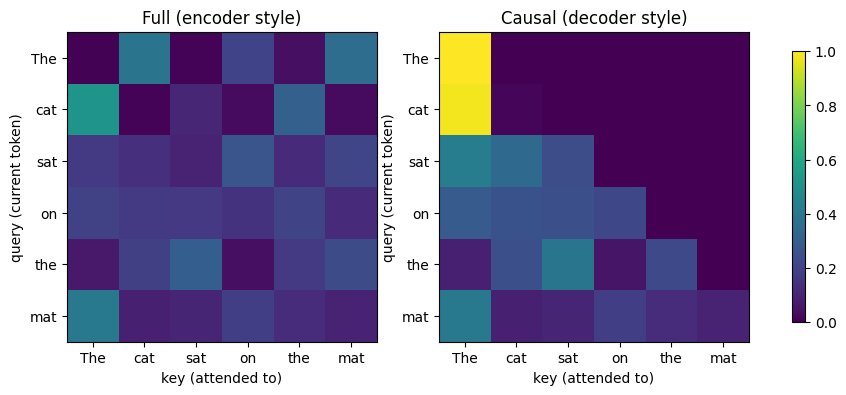

In [31]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.shape[-1]
    scores = Q @ K.swapaxes(-1, -2) / np.sqrt(d_k)
    if mask is not None:
        scores = np.where(mask, scores, -1e9)
    weights = softmax(scores, axis=-1)
    return weights @ V, weights

def causal_mask(T):
    return np.tril(np.ones((T, T), dtype=bool))

rng = np.random.default_rng(3)
T, d = 6, 8
tokens = ["The", "cat", "sat", "on", "the", "mat"]

Q = rng.normal(size=(T, d))
K = rng.normal(size=(T, d))
V = rng.normal(size=(T, d))

out_full, w_full = scaled_dot_product_attention(Q, K, V)
out_causal, w_causal = scaled_dot_product_attention(Q, K, V, mask=causal_mask(T))

print("output shape:", out_causal.shape)
print("rows sum to 1:", np.allclose(w_causal.sum(axis=-1), 1))
print("future weights are zero:", np.allclose(np.triu(w_causal, k=1), 0))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, w, title in zip(axes, [w_full, w_causal], ["Full (encoder style)", "Causal (decoder style)"]):
    im = ax.imshow(w, cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(T))
    ax.set_xticklabels(tokens)
    ax.set_yticks(range(T))
    ax.set_yticklabels(tokens)
    ax.set_xlabel("key (attended to)")
    ax.set_ylabel("query (current token)")
    ax.set_title(title)
    ax.grid(False)
fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()

### 8.6 Multi-head attention

Instead of one attention operation, Transformers run several in parallel on lower-dimensional slices (heads), then concatenate the results. This is a pure reshape, transpose and batched matmul exercise, which is exactly what NumPy is good at.

input  : (6, 16)
output : (6, 16)
attention weights (heads, T, T): (4, 6, 6)


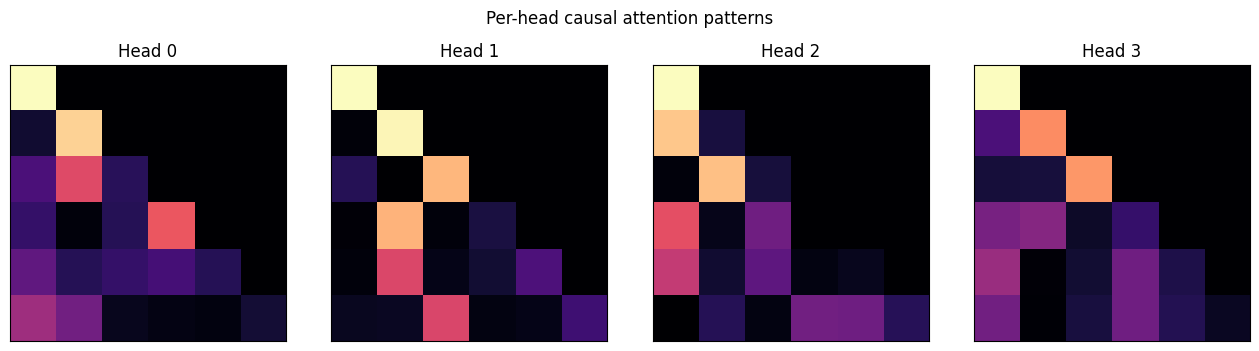

In [32]:
def multi_head_attention(x, Wq, Wk, Wv, Wo, n_heads, mask=None):
    T, d_model = x.shape
    d_head = d_model // n_heads

    def split_heads(M):
        return M.reshape(T, n_heads, d_head).transpose(1, 0, 2)   # (heads, T, d_head)

    Q, K, V = split_heads(x @ Wq), split_heads(x @ Wk), split_heads(x @ Wv)
    out, weights = scaled_dot_product_attention(Q, K, V, mask=mask)   # mask broadcasts over heads
    out = out.transpose(1, 0, 2).reshape(T, d_model)                  # merge heads
    return out @ Wo, weights

rng = np.random.default_rng(8)
T, d_model, n_heads = 6, 16, 4
x = rng.normal(size=(T, d_model))
Wq, Wk, Wv, Wo = (rng.normal(size=(d_model, d_model)) / np.sqrt(d_model) for _ in range(4))

out, w = multi_head_attention(x, Wq, Wk, Wv, Wo, n_heads, mask=causal_mask(T))
print("input  :", x.shape)
print("output :", out.shape)
print("attention weights (heads, T, T):", w.shape)

fig, axes = plt.subplots(1, n_heads, figsize=(13, 3.4))
for h, ax in enumerate(axes):
    ax.imshow(w[h], cmap="magma", vmin=0, vmax=1)
    ax.set_title(f"Head {h}")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
plt.suptitle("Per-head causal attention patterns", y=1.02)
plt.tight_layout()
plt.show()

### 8.7 Sinusoidal positional encoding

Attention by itself has no notion of word order. The original Transformer adds a position-dependent vector to each token embedding:

```
PE(pos, 2i)   = sin(pos / 10000^(2i / d_model))
PE(pos, 2i+1) = cos(pos / 10000^(2i / d_model))
```

Each dimension oscillates at a different frequency, giving every position a unique, smoothly varying signature.

shape: (64, 32)


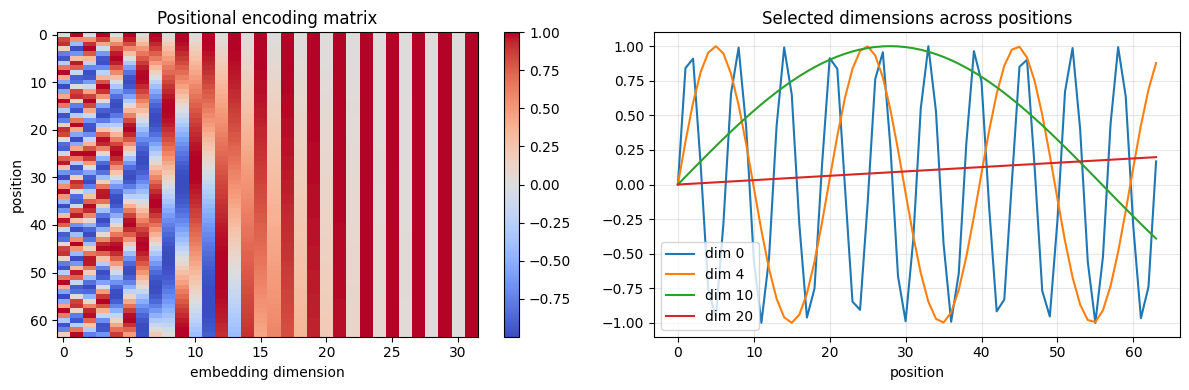

In [33]:
def sinusoidal_positional_encoding(max_len, d_model):
    pos = np.arange(max_len)[:, None]                       # (max_len, 1)
    i = np.arange(d_model // 2)[None, :]                    # (1, d_model/2)
    angle = pos / np.power(10000.0, 2 * i / d_model)
    pe = np.zeros((max_len, d_model))
    pe[:, 0::2] = np.sin(angle)
    pe[:, 1::2] = np.cos(angle)
    return pe

pe = sinusoidal_positional_encoding(64, 32)
print("shape:", pe.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im = axes[0].imshow(pe, aspect="auto", cmap="coolwarm")
axes[0].set_xlabel("embedding dimension")
axes[0].set_ylabel("position")
axes[0].set_title("Positional encoding matrix")
axes[0].grid(False)
fig.colorbar(im, ax=axes[0])

for dim in [0, 4, 10, 20]:
    axes[1].plot(pe[:, dim], label=f"dim {dim}")
axes[1].set_title("Selected dimensions across positions")
axes[1].set_xlabel("position")
axes[1].legend()
plt.tight_layout()
plt.show()

### 8.8 Layer normalization

Transformers normalize activations across the feature dimension for each token independently, then apply a learned scale (`gamma`) and shift (`beta`). This keeps activations in a stable range during training.

In [34]:
def layer_norm(x, gamma, beta, eps=1e-5):
    mean = x.mean(axis=-1, keepdims=True)
    var = x.var(axis=-1, keepdims=True)
    return gamma * (x - mean) / np.sqrt(var + eps) + beta

rng = np.random.default_rng(9)
x = rng.normal(loc=5.0, scale=3.0, size=(4, 16))      # (tokens, features) with an awkward scale
gamma, beta = np.ones(16), np.zeros(16)
y = layer_norm(x, gamma, beta)

print("before -> mean per token:", x.mean(axis=-1).round(2))
print("before -> std  per token:", x.std(axis=-1).round(2))
print("after  -> mean per token:", y.mean(axis=-1).round(4))
print("after  -> std  per token:", y.std(axis=-1).round(4))

before -> mean per token: [5.28 5.18 4.44 4.37]
before -> std  per token: [3.32 3.18 2.69 2.86]
after  -> mean per token: [-0.  0.  0.  0.]
after  -> std  per token: [1. 1. 1. 1.]


### 8.9 Training a model from scratch: logistic regression with gradient descent

Frameworks compute gradients automatically, but the underlying math is plain array algebra. For logistic regression:

- Prediction: `p = sigmoid(X w + b)`
- Loss: binary cross-entropy
- Gradient: `dw = X^T (p - y) / n`, `db = mean(p - y)`

Training this model shows the full loop of forward pass, loss, backward pass and parameter update that every neural network follows.

In [35]:
rng = np.random.default_rng(1)
n = 300
X0 = rng.normal(loc=[-1.5, -1.0], scale=1.0, size=(n // 2, 2))
X1 = rng.normal(loc=[1.5, 1.0], scale=1.0, size=(n // 2, 2))
X = np.vstack([X0, X1])
y = np.array([0] * (n // 2) + [1] * (n // 2))

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def bce(p, y, eps=1e-9):
    return -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))

w = np.zeros(2)
b = 0.0
lr = 0.3
losses, accs = [], []

for step in range(200):
    p = sigmoid(X @ w + b)                 # forward
    losses.append(bce(p, y))
    accs.append(((p > 0.5) == y).mean())
    dw = X.T @ (p - y) / n                 # backward
    db = np.mean(p - y)
    w -= lr * dw                           # update
    b -= lr * db

print(f"final loss    : {losses[-1]:.4f}")
print(f"final accuracy: {accs[-1]:.3f}")
print("weights       :", w.round(3), "bias:", round(b, 3))

final loss    : 0.0666
final accuracy: 0.980
weights       : [2.338 1.746] bias: 0.421


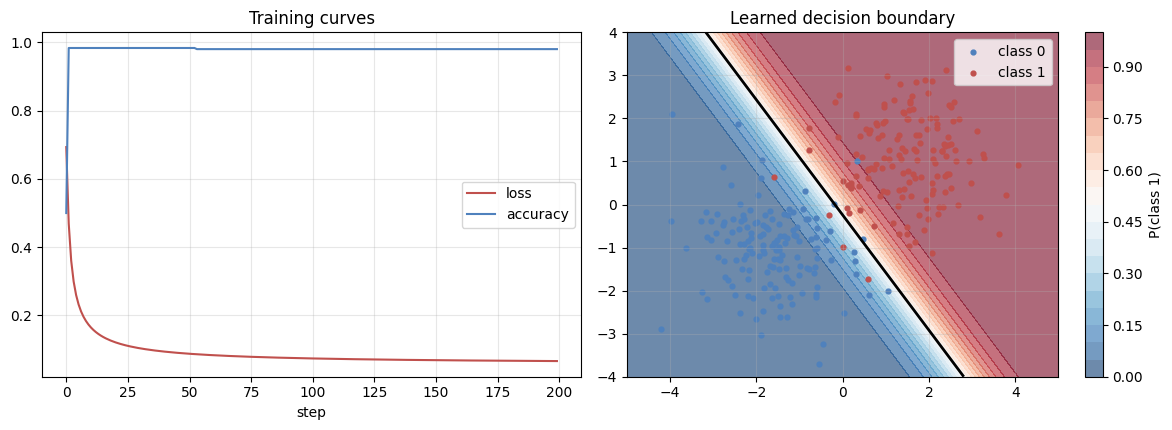

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

axes[0].plot(losses, label="loss", color="#c0504d")
axes[0].plot(accs, label="accuracy", color="#4f81bd")
axes[0].set_xlabel("step")
axes[0].set_title("Training curves")
axes[0].legend()

xx, yy = np.meshgrid(np.linspace(-5, 5, 200), np.linspace(-4, 4, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
zz = sigmoid(grid @ w + b).reshape(xx.shape)
cs = axes[1].contourf(xx, yy, zz, levels=20, cmap="RdBu_r", alpha=0.6)
axes[1].contour(xx, yy, zz, levels=[0.5], colors="black", linewidths=2)
axes[1].scatter(X[y == 0, 0], X[y == 0, 1], s=12, color="#4f81bd", label="class 0")
axes[1].scatter(X[y == 1, 0], X[y == 1, 1], s=12, color="#c0504d", label="class 1")
axes[1].set_title("Learned decision boundary")
axes[1].legend()
fig.colorbar(cs, ax=axes[1], label="P(class 1)")
plt.tight_layout()
plt.show()

### 8.10 Quantization: shrinking models with int8

Serving large models is expensive, so weights are often compressed from float32 to int8. **Symmetric linear quantization** maps floats to integers using a scale factor:

```
scale = max(|W|) / 127
W_int8 = round(W / scale)
W_approx = W_int8 * scale
```

Memory drops by 4x. The cost is a small rounding error, which usually has little effect on model quality when applied carefully (for example per-channel scales).

float32 size       : 4.19 MB
int8 size          : 1.05 MB  (4x smaller)
mean abs error, per-tensor scale : 0.002953
mean abs error, per-row scale    : 0.000341
relative output error (per-row)  : 0.00829


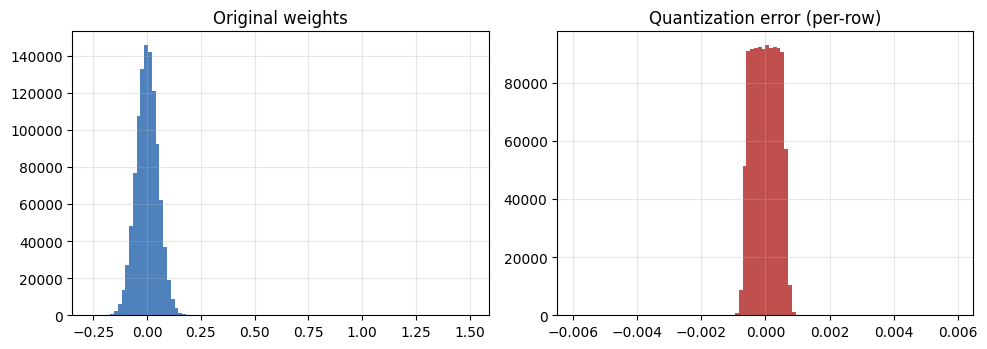

In [37]:
def quantize_int8(W, axis=None):
    max_abs = np.max(np.abs(W), axis=axis, keepdims=True) if axis is not None else np.max(np.abs(W))
    scale = max_abs / 127.0
    q = np.clip(np.round(W / scale), -127, 127).astype(np.int8)
    return q, scale

def dequantize(q, scale):
    return q.astype(np.float32) * scale

rng = np.random.default_rng(2)
W = rng.normal(scale=0.05, size=(1024, 1024)).astype(np.float32)
W[0, 0] = 1.5                                         # a single outlier hurts per-tensor scaling

q_t, s_t = quantize_int8(W)                           # per-tensor
q_c, s_c = quantize_int8(W, axis=1)                   # per-row (per output channel)

err_t = np.abs(W - dequantize(q_t, s_t)).mean()
err_c = np.abs(W - dequantize(q_c, s_c)).mean()

print(f"float32 size       : {W.nbytes / 1e6:.2f} MB")
print(f"int8 size          : {q_t.nbytes / 1e6:.2f} MB  ({W.nbytes / q_t.nbytes:.0f}x smaller)")
print(f"mean abs error, per-tensor scale : {err_t:.6f}")
print(f"mean abs error, per-row scale    : {err_c:.6f}")

x = rng.normal(size=(8, 1024)).astype(np.float32)
ref = x @ W
approx = x @ dequantize(q_c, s_c)
print("relative output error (per-row)  :", (np.linalg.norm(ref - approx) / np.linalg.norm(ref)).round(5))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].hist(W.ravel(), bins=100, color="#4f81bd")
axes[0].set_title("Original weights")
axes[1].hist((W - dequantize(q_c, s_c)).ravel(), bins=100, color="#c0504d")
axes[1].set_title("Quantization error (per-row)")
plt.tight_layout()
plt.show()

### 8.11 Padding and batching variable-length sequences

Real text batches contain sentences of different lengths. To stack them in one array you pad to the longest length and carry a **mask** so the model ignores padding. This combines fancy indexing, broadcasting and boolean masks.

In [38]:
sequences = [
    [5, 12, 7],
    [3, 9],
    [8, 4, 6, 2, 11],
    [1],
]
PAD = 0

max_len = max(len(s) for s in sequences)
batch = np.full((len(sequences), max_len), PAD, dtype=np.int64)
for i, s in enumerate(sequences):
    batch[i, :len(s)] = s

pad_mask = batch != PAD                                   # True for real tokens
print("padded batch:\n", batch)
print("\npadding mask:\n", pad_mask.astype(int))

# Use the mask to compute a correct mean over real tokens only
rng = np.random.default_rng(0)
emb = rng.normal(size=(20, 4))
vecs = emb[batch]                                         # (batch, seq, features)
mask3 = pad_mask[:, :, None]
mean_pool = (vecs * mask3).sum(axis=1) / mask3.sum(axis=1)
print("\nmasked mean-pooled embeddings shape:", mean_pool.shape)

# Combine padding mask with causal mask for attention: (batch, 1, T, T)
T = max_len
attn_mask = pad_mask[:, None, None, :] & causal_mask(T)[None, None, :, :]
print("combined attention mask shape:", attn_mask.shape)

padded batch:
 [[ 5 12  7  0  0]
 [ 3  9  0  0  0]
 [ 8  4  6  2 11]
 [ 1  0  0  0  0]]

padding mask:
 [[1 1 1 0 0]
 [1 1 0 0 0]
 [1 1 1 1 1]
 [1 0 0 0 0]]

masked mean-pooled embeddings shape: (4, 4)
combined attention mask shape: (4, 1, 5, 5)


### 8.12 Putting it together: a tiny Transformer block forward pass

This combines the earlier pieces: layer norm, multi-head causal attention with a residual connection, then a feed-forward network with GELU and another residual connection. The weights are random, so the output is not meaningful, but the shapes and data flow match a real decoder block.

In [39]:
def gelu(x):
    return 0.5 * x * (1 + np.tanh(np.sqrt(2 / np.pi) * (x + 0.044715 * x ** 3)))

def transformer_block(x, params, n_heads):
    T = x.shape[0]
    h = layer_norm(x, params["g1"], params["b1"])
    attn_out, w = multi_head_attention(h, params["Wq"], params["Wk"], params["Wv"], params["Wo"],
                                       n_heads, mask=causal_mask(T))
    x = x + attn_out                                       # residual
    h = layer_norm(x, params["g2"], params["b2"])
    ff = gelu(h @ params["W1"] + params["c1"]) @ params["W2"] + params["c2"]
    return x + ff, w                                       # residual

rng = np.random.default_rng(11)
d_model, n_heads, d_ff, T = 32, 4, 128, 10
init = lambda *shape: rng.normal(size=shape) / np.sqrt(shape[0])

params = {
    "Wq": init(d_model, d_model), "Wk": init(d_model, d_model),
    "Wv": init(d_model, d_model), "Wo": init(d_model, d_model),
    "W1": init(d_model, d_ff), "c1": np.zeros(d_ff),
    "W2": init(d_ff, d_model), "c2": np.zeros(d_model),
    "g1": np.ones(d_model), "b1": np.zeros(d_model),
    "g2": np.ones(d_model), "b2": np.zeros(d_model),
}

token_ids = rng.integers(0, 100, size=T)
embedding = rng.normal(size=(100, d_model))
x = embedding[token_ids] + sinusoidal_positional_encoding(T, d_model)

y, attn = transformer_block(x, params, n_heads)
n_params = sum(v.size for v in params.values())
print("input shape     :", x.shape)
print("output shape    :", y.shape)
print("block parameters:", n_params)

input shape     : (10, 32)
output shape    : (10, 32)
block parameters: 12576


## 9. Performance and good practice

**Do**

- Prefer vectorized operations and `@`/`einsum` over Python loops.
- Choose the smallest dtype that keeps accuracy acceptable (`float32` is the usual default for ML).
- Pre-allocate output arrays (`np.empty`, `np.zeros`) when building results in a loop.
- Use `keepdims=True` to keep shapes broadcast-friendly.
- Use `np.random.default_rng(seed)` for reproducibility.
- Use `out=` arguments and in-place operators (`+=`) to avoid temporary arrays on large data.

**Avoid**

- Growing arrays with repeated `np.append` or `np.concatenate` in a loop.
- Mixing dtypes accidentally; `float64` silently doubles memory.
- Relying on exact float equality; use `np.isclose` and `np.allclose`.
- Forgetting that slices are views while fancy indexing makes copies.

### Quick benchmark: temporaries versus in-place

In [40]:
x = np.random.default_rng(0).random(5_000_000).astype(np.float32)

t0 = time.perf_counter()
for _ in range(20):
    y = x * 2.0 + 1.0                  # allocates temporaries
t_temp = time.perf_counter() - t0

buf = np.empty_like(x)
t0 = time.perf_counter()
for _ in range(20):
    np.multiply(x, 2.0, out=buf)
    buf += 1.0                         # reuses one buffer
t_inplace = time.perf_counter() - t0

print(f"with temporaries: {t_temp * 1000:7.1f} ms")
print(f"in-place buffer : {t_inplace * 1000:7.1f} ms")

with temporaries:    64.0 ms
in-place buffer :    41.9 ms


### How NumPy relates to deep learning frameworks

| Concept | NumPy | PyTorch / JAX / TensorFlow |
|---|---|---|
| N-d array | `ndarray` | `Tensor` / `Array` |
| Runs on | CPU | CPU, GPU, TPU |
| Automatic differentiation | No | Yes |
| API style | Reference for array semantics | Deliberately similar to NumPy |
| Typical role in AI work | Data prep, prototyping, teaching, evaluation, post-processing | Training and serving models |

Conversion is cheap. `torch.from_numpy(arr)` and `tensor.numpy()` share memory on CPU, and `jax.numpy` mirrors the NumPy API almost function for function.

## 10. Exercises

1. **Broadcasting.** Given a `(100, 3)` array of RGB pixels and a `(3,)` array of channel means, subtract the means without a loop.
2. **Masking.** Create a `(5, 5)` boolean mask that allows each token to attend only to itself and the two previous tokens (a sliding-window attention mask).
3. **Sampling.** Implement `min_p` sampling: keep tokens whose probability is at least `min_p` times the top probability.
4. **Cosine search.** Extend `top_k_similar` to accept a batch of queries `(Q, d)` and return an index matrix of shape `(Q, k)`.
5. **Initialization.** Repeat the activation-scale experiment using Xavier initialization with tanh activations and compare with ReLU plus He initialization.
6. **Quantization.** Implement int4 symmetric quantization (range -7 to 7) and measure the error against int8.
7. **Gradient check.** Verify the logistic regression gradients using finite differences: `(loss(w + h) - loss(w - h)) / (2h)`.

## 11. Summary

- NumPy's `ndarray` provides fast, typed, strided storage; understanding shapes, dtypes, views and copies prevents most bugs.
- Vectorization and broadcasting replace loops and are the reason Python is viable for numerical work.
- Linear algebra (`matmul`, `einsum`, SVD) is the engine of neural networks, retrieval and compression.
- Embedding lookup, cosine search, softmax sampling, attention, layer norm, quantization and batching are all a handful of NumPy operations.
- Frameworks add GPUs and automatic differentiation, but the array semantics you learned here carry over directly.

**Next steps:** explore `scipy` for sparse matrices and optimization, `pandas` for tabular data, then re-implement the attention and training examples in PyTorch or JAX to see the same ideas on accelerators.